# PyKEEN KGE Benchmark Case Study

This notebook compares four knowledge graph embedding models in a controlled PyKEEN setup:

- `TransE`
- `PairRE`
- `DistMult`
- `ConvE`

The notebook supports two benchmark modes:

- `minimal`: a small and fast benchmark on `Nations`
- `complete`: a broader benchmark on larger datasets with much longer training times

Both modes keep the data split and evaluation protocol fixed within each dataset and compare:

- Mean Reciprocal Rank (`MRR`)
- `Hits@1`, `Hits@3`, `Hits@10`
- training time
- parameter count

The checked-in notebook is intended to be re-runnable. By default it uses the `minimal` mode because `complete` takes much longer.


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

from benchmark_case_study import (
    RANDOM_SEED,
    get_benchmark_config,
    get_dataset_summaries,
    run_case_study,
    save_case_study_artifacts,
)

plt.style.use('seaborn-v0_8-whitegrid')

## Choose benchmark mode

Set `BENCHMARK_MODE` to one of the following:

- `minimal` for the fast student-sized benchmark on `Nations`
- `complete` for the larger multi-dataset benchmark on `Kinships` and `UMLS`


In [2]:
BENCHMARK_MODE = 'minimal'

In [3]:
config = get_benchmark_config(BENCHMARK_MODE)
dataset_summaries = pd.DataFrame(get_dataset_summaries(BENCHMARK_MODE))

setup = pd.DataFrame(
    [
        ('Mode', BENCHMARK_MODE),
        ('Description', config['description']),
        ('Datasets', ', '.join(config['datasets'])),
        ('Models', ', '.join(model['model'] for model in config['models'])),
        ('Random seed', RANDOM_SEED),
        ('Embedding dimension', config['embedding_dim']),
        ('Epochs', config['num_epochs']),
        ('Batch size', config['batch_size']),
        ('Learning rate', config['learning_rate']),
        ('Inverse triples', config['create_inverse_triples']),
        ('Evaluation', 'Filtered ranking metrics on each fixed test split'),
    ],
    columns=['Setting', 'Value'],
)

setup

,Setting,Value
0,Mode,minimal
1,Description,"Small, fast benchmark on Nations for a compact..."
2,Datasets,Nations
3,Models,"TransE, PairRE, DistMult, ConvE"
4,Random seed,42
5,Embedding dimension,64
6,Epochs,30
7,Batch size,128
8,Learning rate,0.001
9,Inverse triples,True


## Dataset summary

The benchmark keeps each dataset's predefined train, validation, and test split fixed.


In [4]:
dataset_summaries

,dataset,training_triples,validation_triples,testing_triples,entities,relations
0,Nations,1592,199,201,14,110


## Run benchmark

This cell trains all selected models for the chosen benchmark mode and saves artifacts to `results/<mode>/`.


In [5]:
results, losses, dataset_summaries_list, config = run_case_study(mode=BENCHMARK_MODE)
output_dir = save_case_study_artifacts(
    results=results,
    losses=losses,
    dataset_summaries=dataset_summaries_list,
    config=config,
    mode=BENCHMARK_MODE,
)

print(f'Saved artifacts to {output_dir}')
results.head()

Saved artifacts to results/minimal


,dataset,model,train_seconds,parameter_count,mrr,hits@1,hits@3,hits@10
0,Nations,PairRE,2.734464,14976,0.698927,0.544776,0.830846,0.985075
1,Nations,ConvE,7.118577,94352,0.687627,0.542289,0.773632,0.985075
2,Nations,DistMult,2.508326,7936,0.671206,0.524876,0.768657,0.967662
3,Nations,TransE,2.524974,7936,0.340164,0.000000,0.562189,0.972637


In [6]:
results_rounded = results.copy()
for column in ['train_seconds', 'mrr', 'hits@1', 'hits@3', 'hits@10']:
    results_rounded[column] = results_rounded[column].round(4)
results_rounded

,dataset,model,train_seconds,parameter_count,mrr,hits@1,hits@3,hits@10
0,Nations,PairRE,2.7345,14976,0.6989,0.5448,0.8308,0.9851
1,Nations,ConvE,7.1186,94352,0.6876,0.5423,0.7736,0.9851
2,Nations,DistMult,2.5083,7936,0.6712,0.5249,0.7687,0.9677
3,Nations,TransE,2.5250,7936,0.3402,0.0000,0.5622,0.9726


## Aggregate comparison

For the complete benchmark, it helps to average the results across datasets to see which model is strongest overall.


In [7]:
summary_by_model = (
    results.groupby('model', as_index=False)
    .agg(
        mean_train_seconds=('train_seconds', 'mean'),
        mean_parameter_count=('parameter_count', 'mean'),
        mean_mrr=('mrr', 'mean'),
        mean_hits_at_1=('hits@1', 'mean'),
        mean_hits_at_3=('hits@3', 'mean'),
        mean_hits_at_10=('hits@10', 'mean'),
    )
    .sort_values('mean_mrr', ascending=False)
    .reset_index(drop=True)
)

summary_by_model.round(4)

,model,mean_train_seconds,mean_parameter_count,mean_mrr,mean_hits_at_1,mean_hits_at_3,mean_hits_at_10
0,PairRE,2.7345,14976.0,0.6989,0.5448,0.8308,0.9851
1,ConvE,7.1186,94352.0,0.6876,0.5423,0.7736,0.9851
2,DistMult,2.5083,7936.0,0.6712,0.5249,0.7687,0.9677
3,TransE,2.5250,7936.0,0.3402,0.0000,0.5622,0.9726


## Quality comparison

The plots below compare ranking quality. In complete mode, each dataset gets its own panel so the comparison stays easy to read.


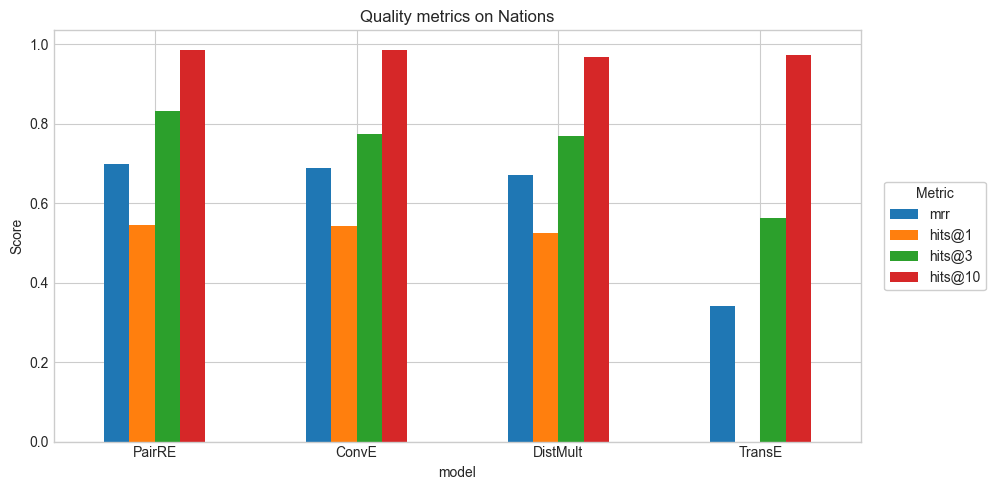

In [8]:
metric_columns = ['mrr', 'hits@1', 'hits@3', 'hits@10']
datasets = list(results['dataset'].unique())
fig, axes = plt.subplots(len(datasets), 1, figsize=(12, 5 * len(datasets)), squeeze=False)

for row_index, dataset_name in enumerate(datasets):
    ax = axes[row_index, 0]
    subset = results.loc[results['dataset'] == dataset_name].set_index('model')[metric_columns]
    subset.plot(kind='bar', ax=ax, rot=0, title=f'Quality metrics on {dataset_name}')
    ax.set_ylabel('Score')
    ax.legend(
        title='Metric',
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        frameon=True,
        facecolor='white',
        framealpha=0.95,
    )

plt.tight_layout(rect=[0, 0, 0.84, 1])
plt.show()

## Efficiency comparison

The next plots compare training time and parameter count for each dataset.


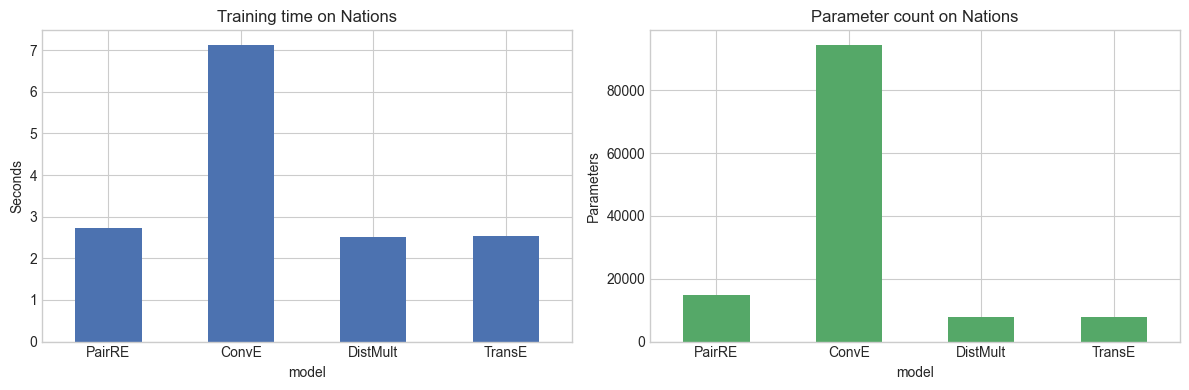

In [9]:
datasets = list(results['dataset'].unique())
fig, axes = plt.subplots(len(datasets), 2, figsize=(12, 4 * len(datasets)), squeeze=False)

for row_index, dataset_name in enumerate(datasets):
    subset = results.loc[results['dataset'] == dataset_name]

    subset.plot(
        x='model',
        y='train_seconds',
        kind='bar',
        legend=False,
        ax=axes[row_index, 0],
        color='#4C72B0',
        rot=0,
        title=f'Training time on {dataset_name}',
    )
    axes[row_index, 0].set_ylabel('Seconds')

    subset.plot(
        x='model',
        y='parameter_count',
        kind='bar',
        legend=False,
        ax=axes[row_index, 1],
        color='#55A868',
        rot=0,
        title=f'Parameter count on {dataset_name}',
    )
    axes[row_index, 1].set_ylabel('Parameters')

plt.tight_layout()
plt.show()

## Training curves

These curves give a simple sanity check that the models trained normally under the shared epoch budget.


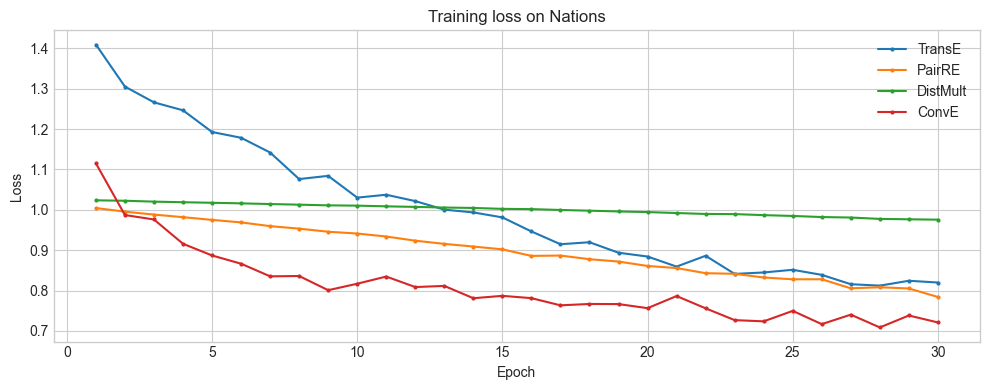

In [10]:
datasets = list(losses.keys())
fig, axes = plt.subplots(len(datasets), 1, figsize=(10, 4 * len(datasets)), squeeze=False)

for row_index, dataset_name in enumerate(datasets):
    ax = axes[row_index, 0]
    for model_name, loss_values in losses[dataset_name].items():
        epochs = range(1, len(loss_values) + 1)
        ax.plot(epochs, loss_values, marker='o', markersize=2, linewidth=1.5, label=model_name)
    ax.set_title(f'Training loss on {dataset_name}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()

plt.tight_layout()
plt.show()

## Model selection rationale

The final recommendation is based mainly on MRR, then checked against training time and parameter count.


In [11]:
best_per_dataset = (
    results.sort_values(['dataset', 'mrr', 'hits@10'], ascending=[True, False, False])
    .groupby('dataset', as_index=False)
    .first()
)

overall_best = summary_by_model.iloc[0]

lines = [
    '### Recommendation',
    '',
    f"For the selected benchmark mode, the strongest overall model is `{overall_best['model']}`.",
    '',
    f"- It has the best average MRR across the evaluated datasets: **{overall_best['mean_mrr']:.4f}**.",
    f"- Its average training time is **{overall_best['mean_train_seconds']:.2f} seconds**.",
    f"- Its average parameter count is **{int(round(overall_best['mean_parameter_count']))}**.",
    '',
    '### Best model by dataset',
    '',
]

for _, row in best_per_dataset.iterrows():
    lines.append(
        f"- `{row['dataset']}`: `{row['model']}` was best with MRR **{row['mrr']:.4f}**, "
        f"training time **{row['train_seconds']:.2f} s**, and **{int(row['parameter_count'])}** parameters."
    )

lines.extend([
    '',
    '### Short discussion',
    '',
    f"- `{overall_best['model']}` is the best final choice because it is strongest on average, not just on one dataset.",
    '- `ConvE` adds an important architectural contrast to the benchmark because it is much more expressive but also much larger.',
    '- The smaller embedding models remain useful baselines because they are easier to train and compare on efficiency.',
])

display(Markdown('\n'.join(lines)))

### Recommendation

For the selected benchmark mode, the strongest overall model is `PairRE`.

- It has the best average MRR across the evaluated datasets: **0.6989**.
- Its average training time is **2.73 seconds**.
- Its average parameter count is **14976**.

### Best model by dataset

- `Nations`: `PairRE` was best with MRR **0.6989**, training time **2.73 s**, and **14976** parameters.

### Short discussion

- `PairRE` is the best final choice because it is strongest on average, not just on one dataset.
- `ConvE` adds an important architectural contrast to the benchmark because it is much more expressive but also much larger.
- The smaller embedding models remain useful baselines because they are easier to train and compare on efficiency.

## Conclusion

This notebook now supports both versions of the assignment:

- a `minimal` benchmark for a fast, compact submission
- a `complete` benchmark with larger datasets and longer training times for a stronger comparison

Both modes satisfy the main case study requirements: fixed evaluation protocol, multiple KGE models, quality metrics, efficiency discussion, and an explicit model choice.
